Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes de fleurs : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Nombre de classes : 5
Nombre d'images par classe (train) :
roses: 521
dandelion: 722
tulips: 642
sunflowers: 547
daisy: 504


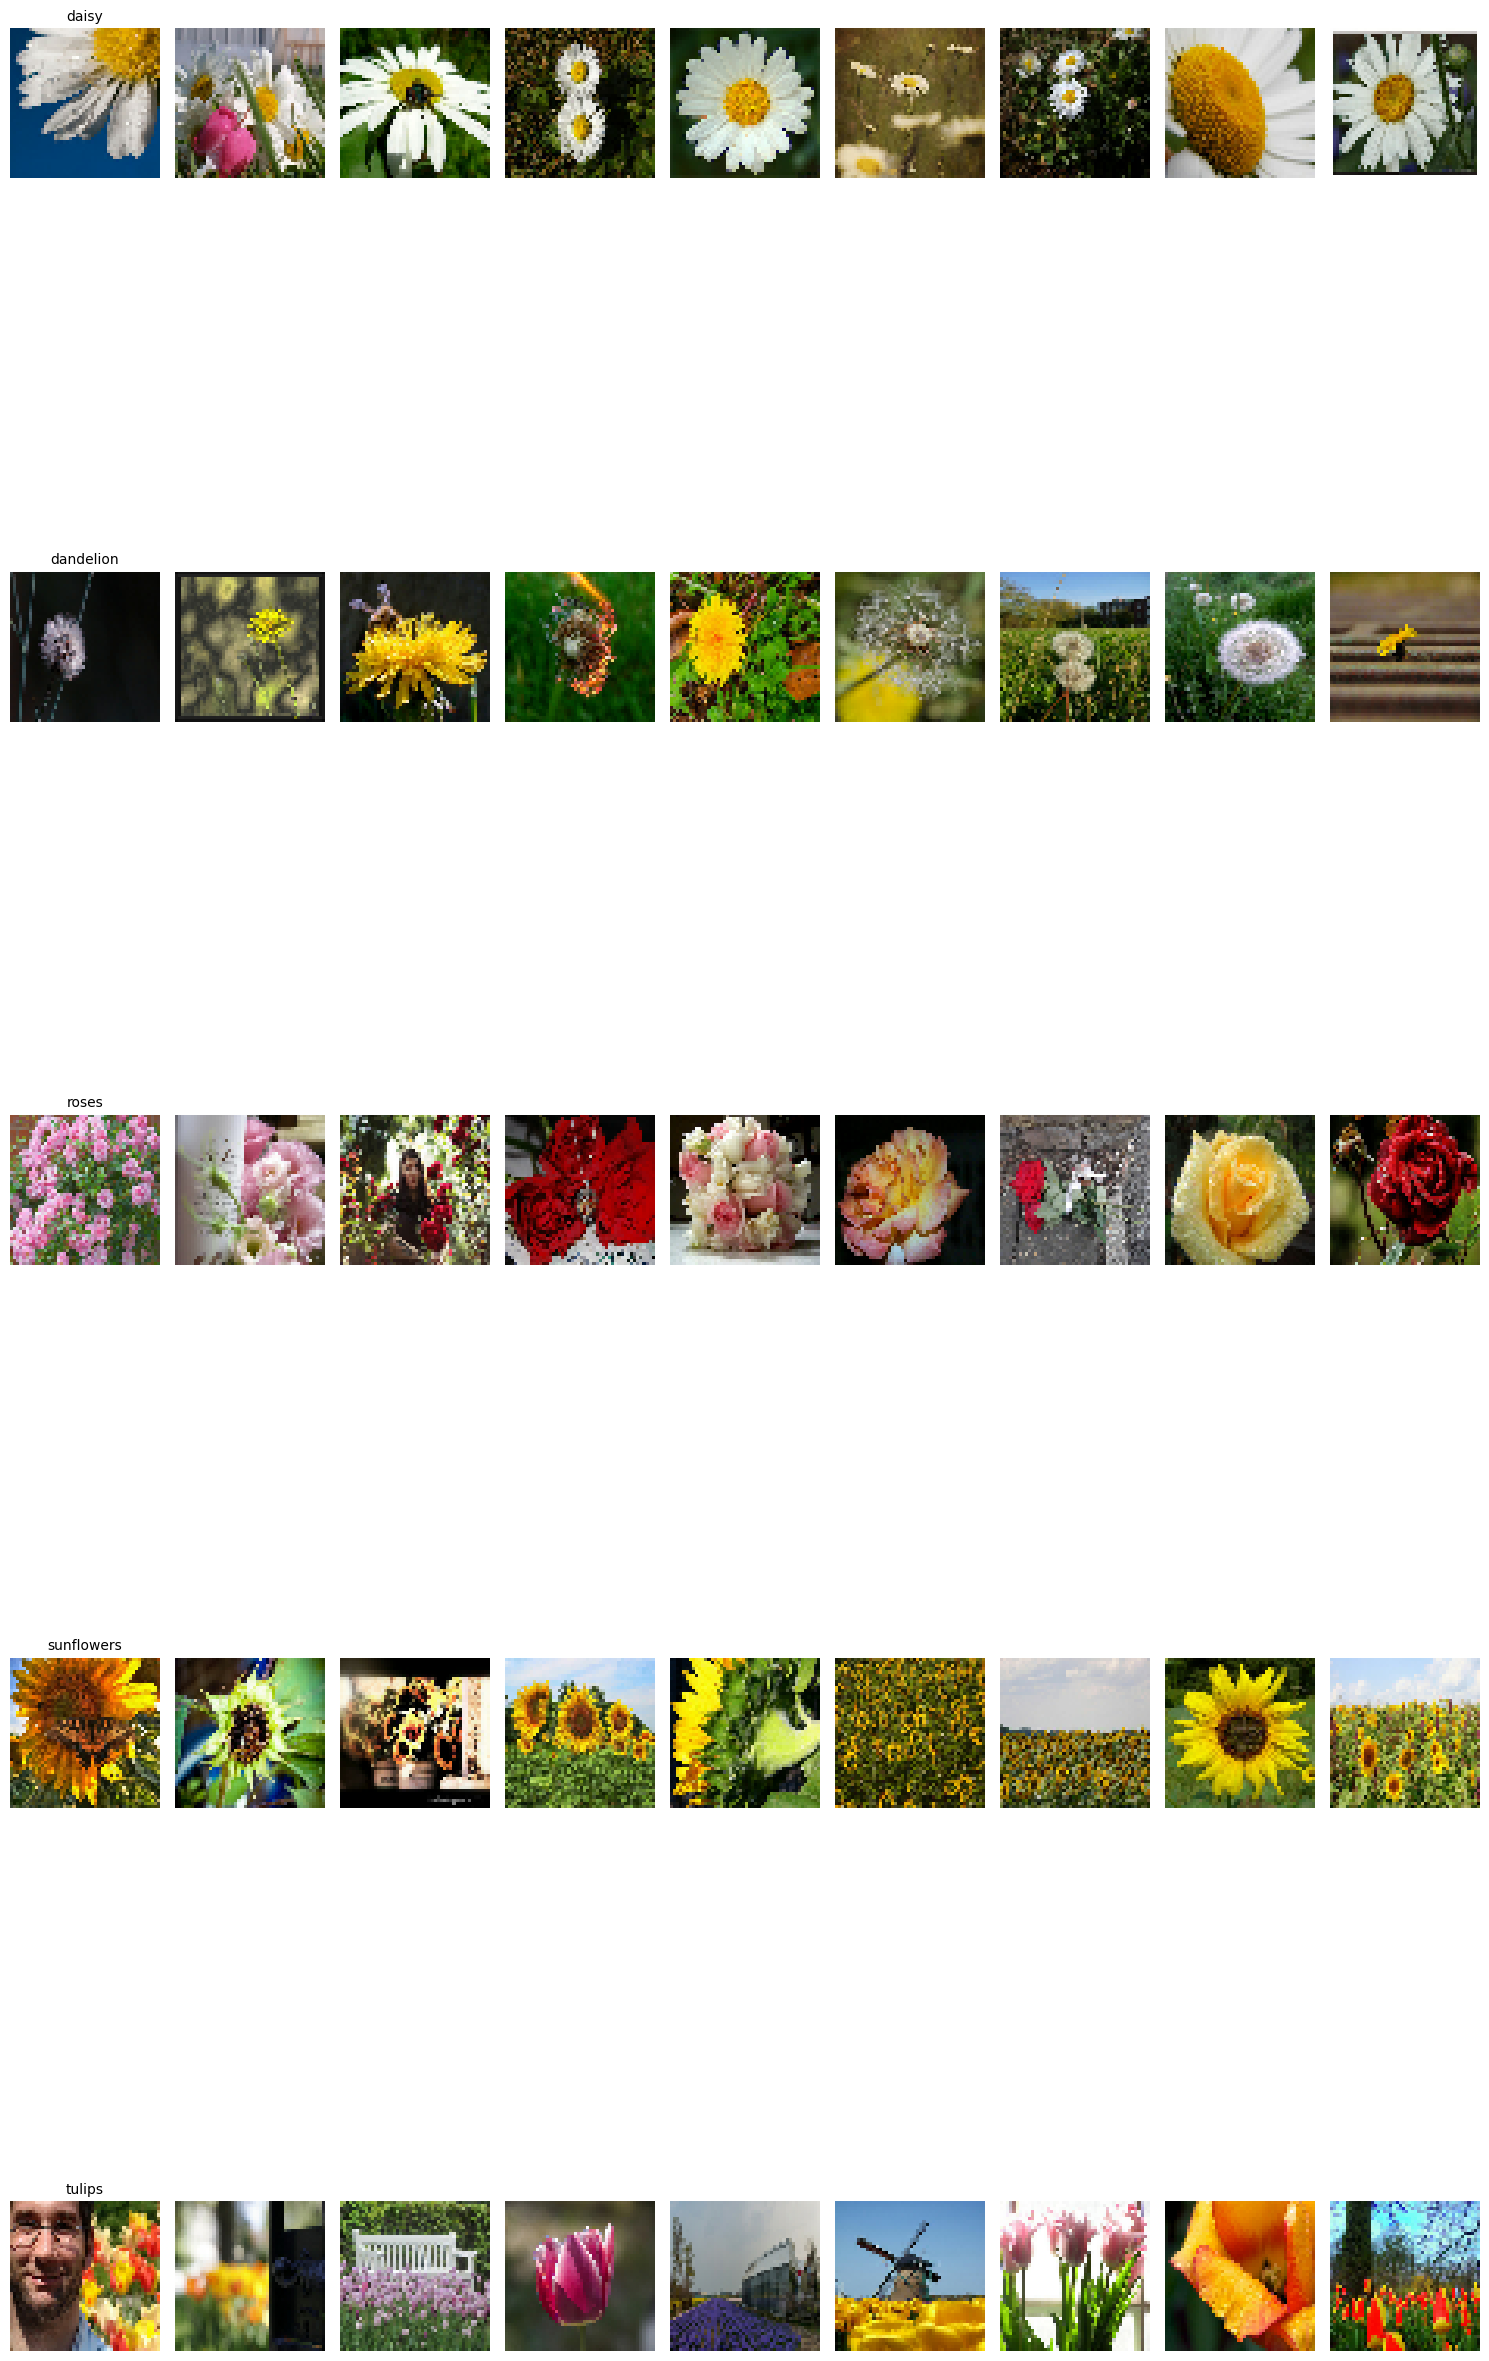


Défis potentiels pour la classification :
1. Similarité des couleurs et formes entre différentes espèces
2. Variations au sein d'une même espèce (taille, couleur, orientation)
3. Conditions d'éclairage variables
4. Présence de fonds complexes ou d'autres objets
5. Différents stades de floraison
6. Angle de prise de vue variable


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Variables globales
HEIGHT = 48
WIDTH = 48
BATCH_SIZE = 32
EPOCHS = 30

# Chargement des données
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/flower_photos',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/flower_photos',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE
)

# Obtenir les noms des classes
class_names = train_ds.class_names
print("Classes de fleurs :", class_names)
print(f"Nombre de classes : {len(class_names)}")

# Compter les images par classe
def count_images_per_class(dataset):
    class_counts = {}
    for images, labels in dataset.unbatch():
        # Ensure labels are processed as integers for class_names indexing
        class_name = class_names[labels.numpy().astype(int)]
        if class_name in class_counts:
            class_counts[class_name] += 1
        else:
            class_counts[class_name] = 1
    return class_counts

train_counts = count_images_per_class(train_ds)
print("Nombre d'images par classe (train) :")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

# Fonction pour visualiser une grille d'images par classe
def visualize_images(dataset, class_names, num_classes=5, images_per_class=9): # Adjusted num_classes to 5 for the flower_photos dataset
    plt.figure(figsize=(15, 30))

    # Iterate through a sample of the dataset to get actual class indices and images
    sampled_images_by_class = {name: [] for name in class_names}

    # Collect a few images per class
    for images, labels in dataset.unbatch():
        class_idx = labels.numpy().astype(int)
        class_name = class_names[class_idx]
        if len(sampled_images_by_class[class_name]) < images_per_class:
            sampled_images_by_class[class_name].append(images.numpy())
        # Break if we have enough images for all classes to avoid iterating through the whole dataset unnecessarily
        if all(len(v) == images_per_class for v in sampled_images_by_class.values()):
            break

    for class_idx, class_name in enumerate(class_names):
        current_class_images = sampled_images_by_class.get(class_name, [])
        for i in range(min(images_per_class, len(current_class_images))):
            plt.subplot(num_classes, images_per_class, class_idx * images_per_class + i + 1)
            # Normaliser pour l'affichage
            img = current_class_images[i].astype(np.float32) / 255.0
            plt.imshow(img)
            plt.axis('off')

            if i == 0:
                plt.title(class_name, fontsize=10)

    plt.tight_layout()
    plt.show()

# Visualiser les images
visualize_images(train_ds, class_names)

# Analyse des défis
print("\nDéfis potentiels pour la classification :")
print("1. Similarité des couleurs et formes entre différentes espèces")
print("2. Variations au sein d'une même espèce (taille, couleur, orientation)")
print("3. Conditions d'éclairage variables")
print("4. Présence de fonds complexes ou d'autres objets")
print("5. Différents stades de floraison")
print("6. Angle de prise de vue variable")

In [9]:
def create_model():
    model = models.Sequential()

    # Bloc de convolution 1
    model.add(tf.keras.Input(shape=(HEIGHT, WIDTH, 3))) # Use Input layer to define input shape
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Bloc de convolution 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Bloc de convolution 3
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Bloc de convolution 4
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Partie dense
    model.add(layers.Flatten())
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))

    # Couche de sortie
    model.add(layers.Dense(len(class_names), activation='softmax'))

    return model

# Création et compilation du modèle
model = create_model()

# Justification des choix architecturaux
print("Justification des choix architecturaux :")
print("1. 4 blocs de convolution avec augmentation progressive des filtres (32→64→128→256)")
print("2. BatchNormalization après chaque couche pour stabiliser l'apprentissage")
print("3. MaxPooling (2x2) pour réduire la dimension spatiale")
print("4. Dropout progressif (0.2→0.5) pour prévenir le surapprentissage")
print("5. Couches denses finales (512→256→14) pour la classification")
print("6. Fonction d'activation softmax pour la classification multiclasse")

# Compilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Justification des choix architecturaux :
1. 4 blocs de convolution avec augmentation progressive des filtres (32→64→128→256)
2. BatchNormalization après chaque couche pour stabiliser l'apprentissage
3. MaxPooling (2x2) pour réduire la dimension spatiale
4. Dropout progressif (0.2→0.5) pour prévenir le surapprentissage
5. Couches denses finales (512→256→14) pour la classification
6. Fonction d'activation softmax pour la classification multiclasse


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 512)            │         2,04

 Total params: 1,706,181 (6.51 MB)

 Trainable params: 1,703,685 (6.50 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [5]:
# Configuration pour l'expérimentation des hyperparamètres
def train_with_hyperparameters(learning_rate=0.001, batch_size=32,
                               optimizer_type='adam', early_stopping=True):
    # Créer un nouveau modèle pour chaque expérience
    model = create_model()

    # Définir l'optimiseur
    if optimizer_type == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_type == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_type == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = []
    if early_stopping:
        callbacks.append(
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )
        )

    # Learning rate scheduler
    callbacks.append(
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=0.00001
        )
    )

    # Entraînement
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

# Expérimenter avec différents hyperparamètres
experiments = [
    {'learning_rate': 0.001, 'optimizer_type': 'adam'},
    {'learning_rate': 0.0001, 'optimizer_type': 'adam'},
    {'learning_rate': 0.001, 'optimizer_type': 'rmsprop'},
    {'learning_rate': 0.001, 'optimizer_type': 'sgd'},
]

results = {}
for i, params in enumerate(experiments):
    print(f"\nExpérience {i+1}: {params}")
    model_exp, history = train_with_hyperparameters(**params)
    val_acc = max(history.history['val_accuracy'])
    results[f"Exp_{i+1}"] = {
        'params': params,
        'val_accuracy': val_acc,
        'history': history
    }

# Afficher les résultats
print("\nRésultats des expériences :")
for name, result in results.items():
    print(f"{name}: {result['params']} -> Val Accuracy: {result['val_accuracy']:.4f}")


Expérience 1: {'learning_rate': 0.001, 'optimizer_type': 'adam'}
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 349ms/step - accuracy: 0.4523 - loss: 1.4134 - val_accuracy: 0.5027 - val_loss: 1.3457 - learning_rate: 0.0010
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 344ms/step - accuracy: 0.5664 - loss: 1.1319 - val_accuracy: 0.6117 - val_loss: 1.0293 - learning_rate: 0.0010
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 359ms/step - accuracy: 0.6012 - loss: 1.0123 - val_accuracy: 0.4837 - val_loss: 1.5670 - learning_rate: 0.0010
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 348ms/step - accuracy: 0.6393 - loss: 0.9243 - val_accuracy: 0.5490 - val_loss: 1.2546 - learning_rate: 0.0010
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.6604 - loss: 0.8803 - val_accuracy: 0.5763 - val_loss: 1.1233 - learning_rate: 0.0010
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 347ms/step - accuracy: 0.7071 - loss: 0.7639 - val_accuracy: 0.5272 - val_loss: 1.2447 - learning_rate: 2.0000e-04
Epoch 7/30
9

In [8]:
# Définition de l'augmentation des données
def create_augmented_generators():
    # Augmentation pour l'entraînement
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Validation sans augmentation
    val_datagen = ImageDataGenerator(rescale=1./255)

    # Chargement des données avec augmentation
    train_generator = train_datagen.flow_from_directory(
        '/content/flower_photos',
        target_size=(HEIGHT, WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='sparse'
    )

    val_generator = val_datagen.flow_from_directory(
        '/content/flower_photos',
        target_size=(HEIGHT, WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='sparse'
    )

    return train_generator, val_generator

# Créer le modèle avec augmentation
def create_model_with_augmentation():
    model = create_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Entraîner avec augmentation
train_gen, val_gen = create_augmented_generators()

model_aug = create_model_with_augmentation()

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
]

history_aug = model_aug.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("Analyse des augmentations efficaces :")
print("1. Rotation : utile car les fleurs peuvent être photographiées sous différents angles")
print("2. Flip horizontal : permet de doubler les données sans perte d'information")
print("3. Zoom : simule différentes distances de prise de vue")
print("4. Shift : les fleurs peuvent être centrées différemment dans l'image")
print("5. Shear : utile pour les variations de perspective")

Found 3670 images belonging to 5 classes.
Found 3670 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 61s 474ms/step - accuracy: 0.4556 - loss: 1.4236 - val_accuracy: 0.2447 - val_loss: 4.1010 - learning_rate: 0.0010
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 472ms/step - accuracy: 0.5553 - loss: 1.1466 - val_accuracy: 0.2447 - val_loss: 4.8441 - learning_rate: 0.0010
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 549ms/step - accuracy: 0.5826 - loss: 1.0461 - val_accuracy: 0.2452 - val_loss: 3.7390 - learning_rate: 0.0010
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 478ms/step - accuracy: 0.6049 - loss: 1.0086 - val_accuracy: 0.3406 - val_loss: 2.1610 - learning_rate: 0.0010
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 552ms/step - accuracy: 0.6401 - loss: 0.9443 - val_accuracy: 0.5354 - val_loss: 1.2482 - learning_rate: 0.0010
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 469ms/step - accuracy: 0.6537 - loss: 0.9003 - val_accuracy: 0.6008 - val_loss: 1.0259 - learning_rate: 0.0010
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 63s 548ms/step - accuracy: 0.6

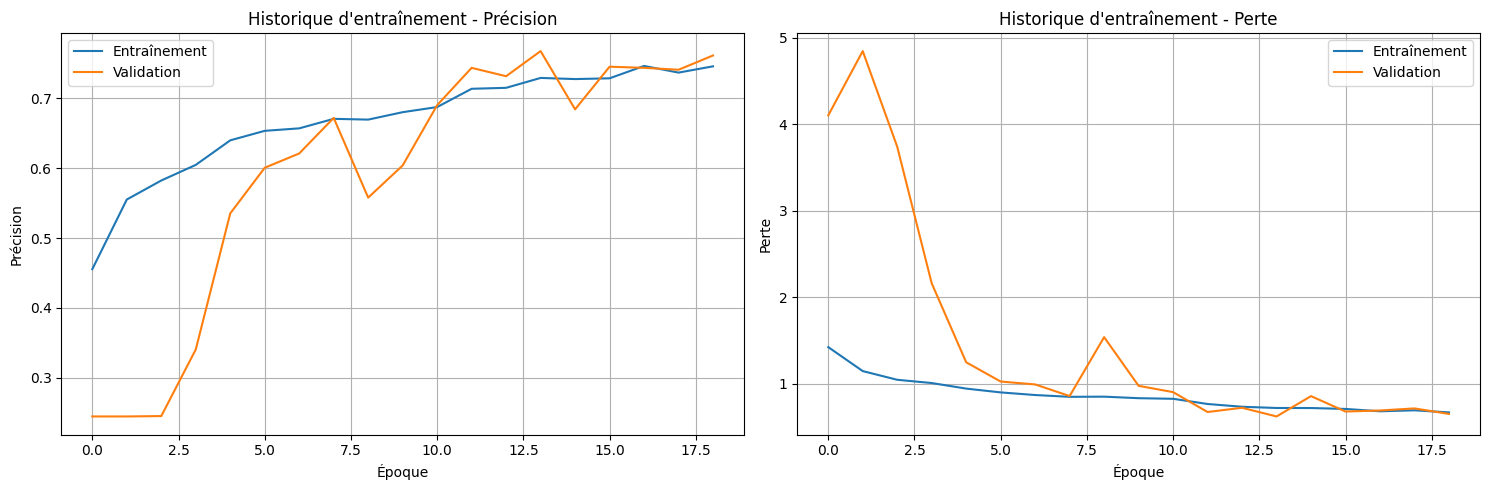

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step


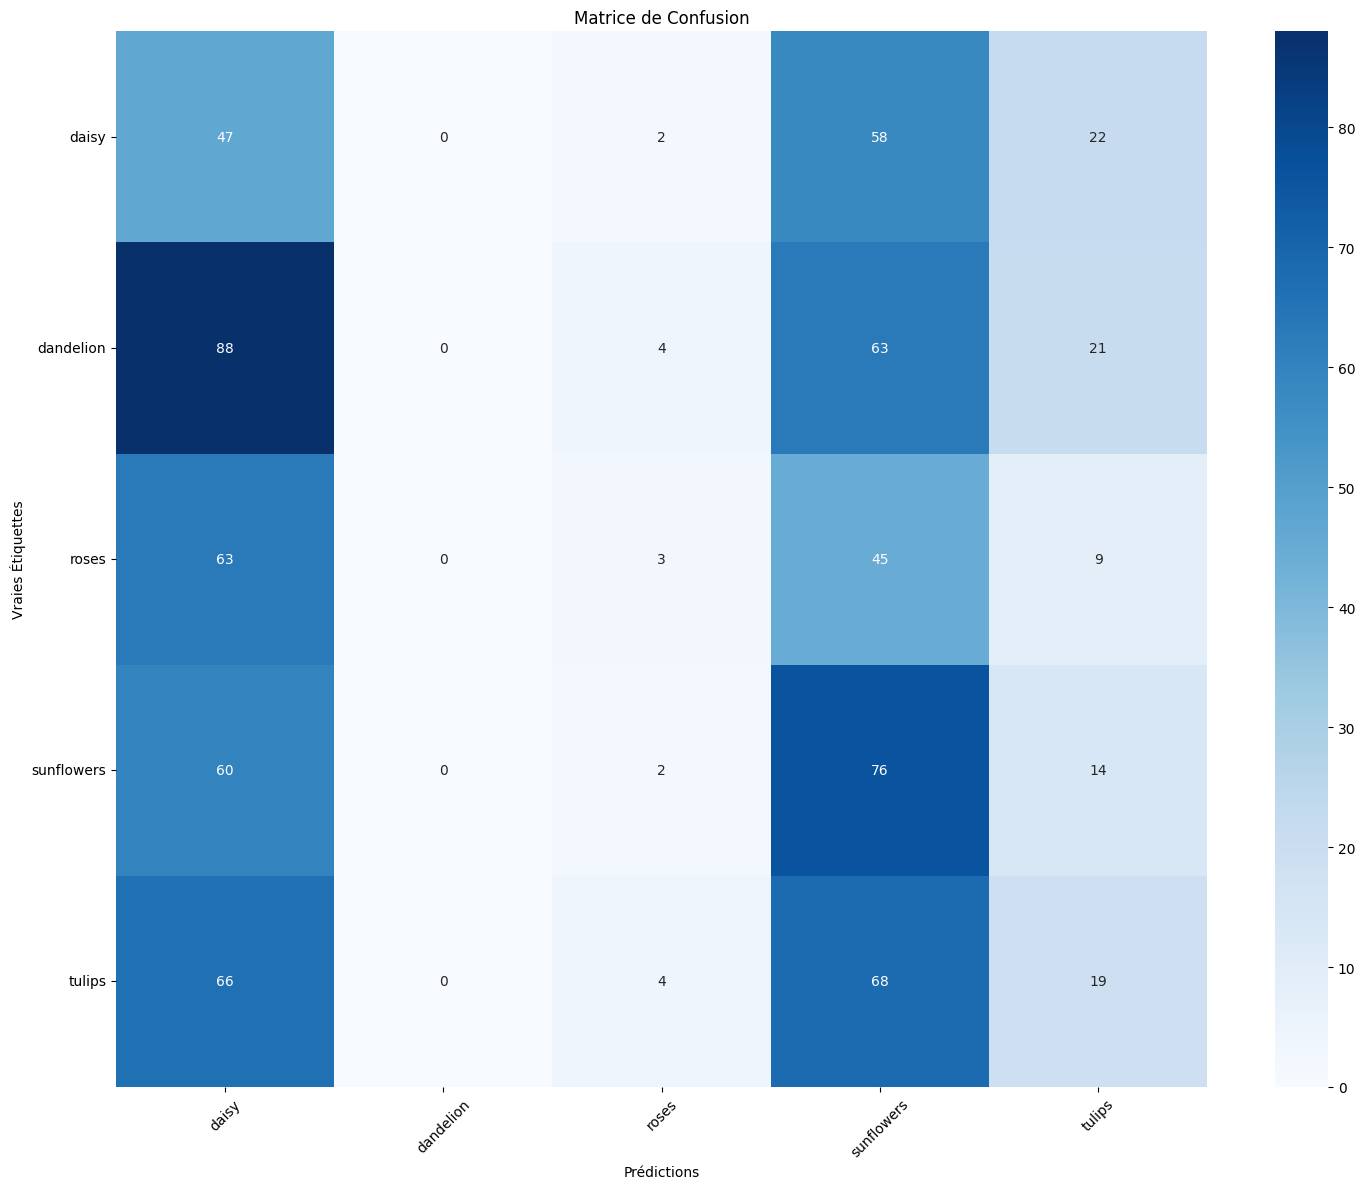

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Rapport de classification :
              precision    recall  f1-score   support

       daisy       0.15      0.36      0.21       129
   dandelion       0.00      0.00      0.00       176
       roses       0.20      0.03      0.04       120
  sunflowers       0.25      0.50      0.33       152
      tulips       0.22      0.12      0.16       157

    accuracy                           0.20       734
   macro avg       0.16      0.20      0.15       734
weighted avg       0.16      0.20      0.15       734

Précision globale : 0.1975

Précision par classe :
daisy: 0.3643
dandelion: 0.0000
roses: 0.0250
sunflowers: 0.5000
tulips: 0.1210

Classes les plus difficiles (<70% de précision) :
- daisy: 0.3643
- dandelion: 0.0000
- roses: 0.0250
- sunflowers: 0.5000
- tulips: 0.1210
Nombre d'erreurs de classification : 589


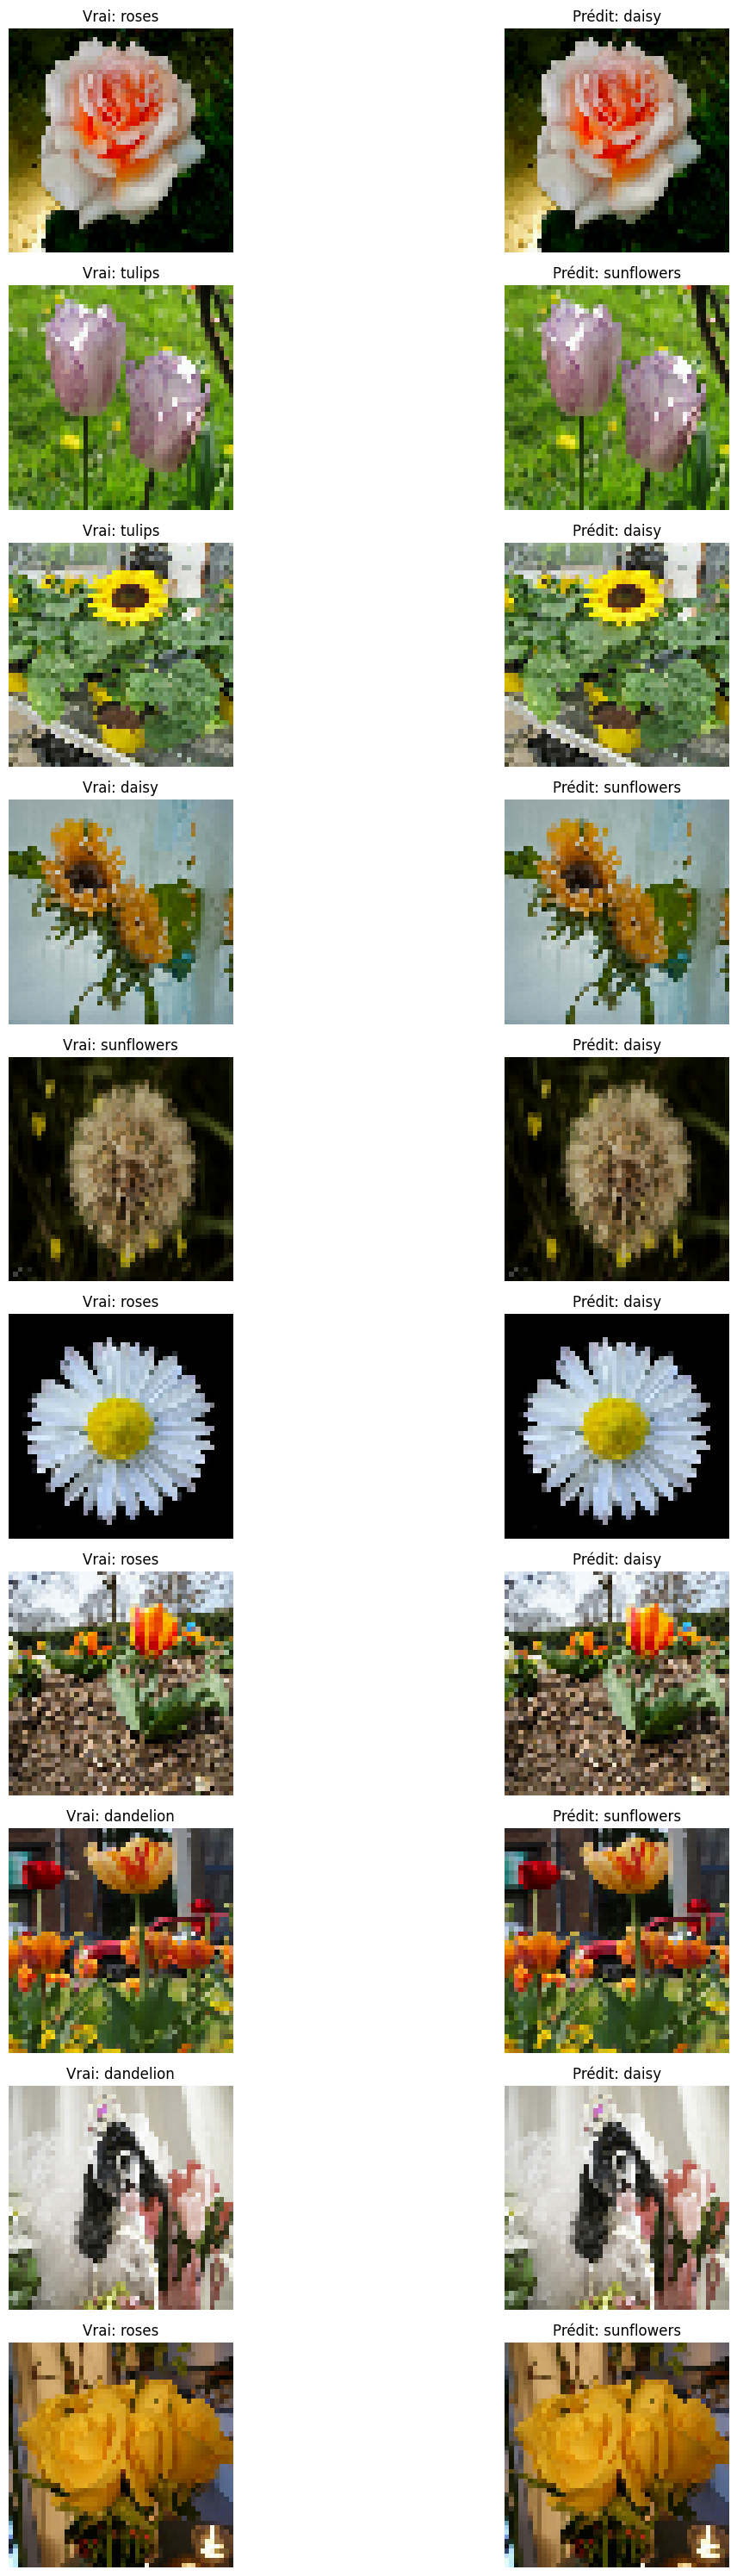


Analyse des erreurs de classification :
Vrai: roses -> Prédit: daisy
Vrai: tulips -> Prédit: sunflowers
Vrai: tulips -> Prédit: daisy
Vrai: daisy -> Prédit: sunflowers
Vrai: sunflowers -> Prédit: daisy
Vrai: roses -> Prédit: daisy
Vrai: roses -> Prédit: daisy
Vrai: dandelion -> Prédit: sunflowers
Vrai: dandelion -> Prédit: daisy
Vrai: roses -> Prédit: sunflowers


In [10]:
# Fonction pour tracer les courbes de précision et de perte
def plot_training_history(history, title="Historique d'entraînement"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Précision
    ax1.plot(history.history['accuracy'], label='Entraînement')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Précision')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Précision')
    ax1.legend()
    ax1.grid(True)

    # Perte
    ax2.plot(history.history['loss'], label='Entraînement')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Perte')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Perte')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_aug)

# Évaluation complète
def evaluate_model(model, val_ds, class_names):
    # Prédictions
    predictions = model.predict(val_ds)
    predicted_classes = np.argmax(predictions, axis=1)

    # Récupération des vraies étiquettes
    true_labels = []
    for _, labels in val_ds.unbatch():
        true_labels.append(labels.numpy())
    true_labels = np.array(true_labels)

    # Matrice de confusion
    cm = confusion_matrix(true_labels, predicted_classes)

    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion')
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies Étiquettes')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Rapport de classification
    report = classification_report(true_labels, predicted_classes,
                                  target_names=class_names)
    print("Rapport de classification :")
    print(report)

    # Précision globale
    accuracy = np.mean(predicted_classes == true_labels)
    print(f"Précision globale : {accuracy:.4f}")

    # Précision par classe
    class_accuracy = {}
    for i, class_name in enumerate(class_names):
        class_mask = (true_labels == i)
        class_acc = np.mean(predicted_classes[class_mask] == true_labels[class_mask])
        class_accuracy[class_name] = class_acc

    print("\nPrécision par classe :")
    for class_name, acc in class_accuracy.items():
        print(f"{class_name}: {acc:.4f}")

    # Classes difficiles
    print("\nClasses les plus difficiles (<70% de précision) :")
    for class_name, acc in class_accuracy.items():
        if acc < 0.7:
            print(f"- {class_name}: {acc:.4f}")

    return true_labels, predicted_classes

true_labels, pred_labels = evaluate_model(model_aug, val_ds, class_names)

# Visualisation des erreurs de classification
def visualize_misclassifications(val_ds, true_labels, pred_labels, class_names, num_examples=10):
    misclassified_indices = np.where(true_labels != pred_labels)[0]
    print(f"Nombre d'erreurs de classification : {len(misclassified_indices)}")

    if len(misclassified_indices) == 0:
        print("Aucune erreur de classification !")
        return

    # Prendre quelques exemples d'erreurs
    sample_indices = np.random.choice(misclassified_indices,
                                     min(num_examples, len(misclassified_indices)),
                                     replace=False)

    # Récupérer les images correspondantes
    images_list = []
    labels_list = []
    for images, labels in val_ds.unbatch():
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())

    images = np.array(images_list)

    plt.figure(figsize=(15, 3 * len(sample_indices)))

    for i, idx in enumerate(sample_indices):
        plt.subplot(len(sample_indices), 2, i*2 + 1)
        img = images[idx].astype(np.float32) / 255.0
        plt.imshow(img)
        plt.title(f"Vrai: {class_names[true_labels[idx]]}")
        plt.axis('off')

        plt.subplot(len(sample_indices), 2, i*2 + 2)
        plt.imshow(img)
        plt.title(f"Prédit: {class_names[pred_labels[idx]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Analyse des erreurs
    print("\nAnalyse des erreurs de classification :")
    for idx in sample_indices:
        true_class = class_names[true_labels[idx]]
        pred_class = class_names[pred_labels[idx]]
        print(f"Vrai: {true_class} -> Prédit: {pred_class}")

visualize_misclassifications(val_ds, true_labels, pred_labels, class_names)